# Consumer Complaint Classification

## 1. Import Libraries

In [23]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load Preprocessed Data

In [24]:
base_path = "/kaggle/input/datasets/mohamedafifi77/files"

 
X_train = np.load(os.path.join(base_path, "X_train.npy"))
X_test = np.load(os.path.join(base_path, "X_test.npy"))

y_train = np.load(os.path.join(base_path, "y_train.npy"))
y_test = np.load(os.path.join(base_path, "y_test.npy"))

 
with open(os.path.join(base_path, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

with open(os.path.join(base_path, "tokenizer.pkl"), "rb") as f:
    tokenizer = pickle.load(f)

 

## 3. Build GRU Model

In [25]:
VOCAB_SIZE = 20000
MAX_LEN = 240

EMBEDDING_DIM = 128

RNN_UNITS = 128

DENSE_UNITS = 64

DROPOUT_RATE = 0.5

BATCH_SIZE = 128

EPOCHS = 20

NUM_CLASSES = len(label_encoder.classes_)

In [26]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    SpatialDropout1D(0.2),

    GRU(
    RNN_UNITS,
    dropout=0.2,
    recurrent_dropout=0.2

    ),

    Dense(
        DENSE_UNITS,
        activation="relu"
    ),

    Dropout(DROPOUT_RATE),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

model.build(input_shape=(None, MAX_LEN))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 240, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 240, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,653 (10.18 MB)

 Trainable params: 2,667,653 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [28]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "/kaggle/working/best_gru.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

## 4. Train Model

In [29]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test, y_test),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.6810 - loss: 0.8442
Epoch 1: val_accuracy improved from None to 0.86615, saving model to /kaggle/working/best_gru.keras

Epoch 1: finished saving model to /kaggle/working/best_gru.keras
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 842s 825ms/step - accuracy: 0.7699 - loss: 0.6291 - val_accuracy: 0.8661 - val_loss: 0.3807 - learning_rate: 0.0010
Epoch 2/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8730 - loss: 0.3861
Epoch 2: val_accuracy improved from 0.86615 to 0.88046, saving model to /kaggle/working/best_gru.keras

Epoch 2: finished saving model to /kaggle/working/best_gru.keras
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 838s 825ms/step - accuracy: 0.8750 - loss: 0.3802 - val_accuracy: 0.8805 - val_loss: 0.3430 - learning_rate: 0.0010
Epoch 3/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8907 - loss: 0.3314
Epoch 3: val_accuracy improved from 0.88046 to 0.88372, saving model to /kaggle/working/best_gru.kera

## 5. Evaluate Model

In [30]:
# Predictions
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

1016/1016 ━━━━━━━━━━━━━━━━━━━━ 170s 167ms/step


In [31]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8837
Precision: 0.8470
Recall   : 0.8516
F1 Score : 0.8491


In [32]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                     precision    recall  f1-score   support

        credit_card       0.79      0.80      0.79      3113
   credit_reporting       0.93      0.93      0.93     18235
    debt_collection       0.81      0.79      0.80      4630
mortgages_and_loans       0.86      0.84      0.85      3798
     retail_banking       0.85      0.91      0.87      2707

           accuracy                           0.88     32483
          macro avg       0.85      0.85      0.85     32483
       weighted avg       0.88      0.88      0.88     32483



## 6. Visualize Results

<Figure size 800x800 with 0 Axes>

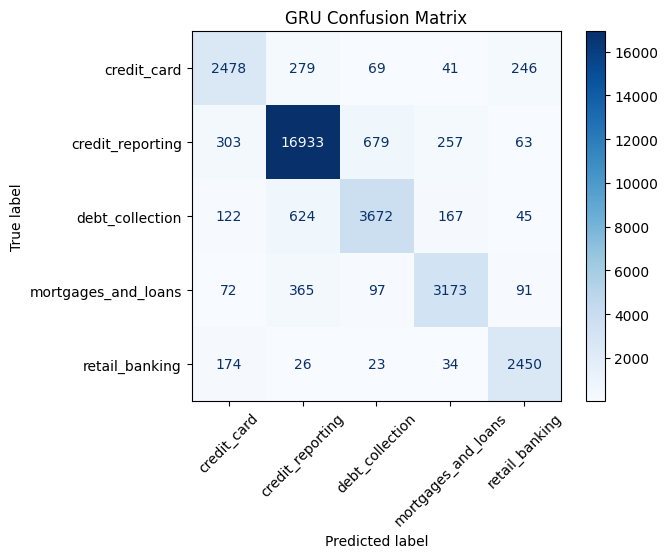

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("GRU Confusion Matrix")

plt.show()

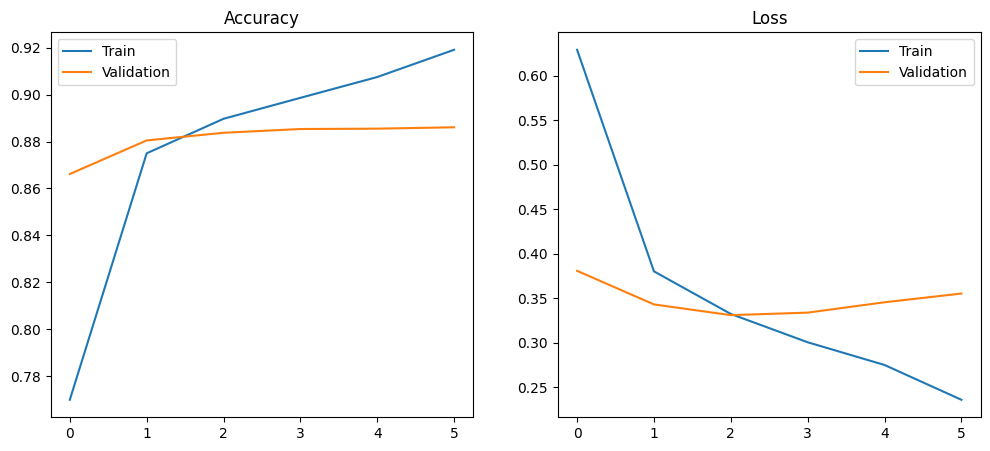

In [34]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")

plt.legend()

plt.show()

## 7. Save 

In [35]:
with open("/kaggle/working/gru_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [36]:
 results = pd.DataFrame({
    "Model": ["GRU"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

results.to_csv("/kaggle/working/gru_results.csv", index=False)

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,GRU,0.883724,0.847025,0.851641,0.849067
